## Лабораторная 4

Работаем строго по методическим указаниям

Импорты:

In [1]:
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.simplefilter('ignore', ConvergenceWarning)
import requests
from io import BytesIO
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.stattools import ccf, adfuller, pacf, acf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.arima_process import arma_generate_sample
from statsmodels.tsa.holtwinters import ExponentialSmoothing, Holt

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = [11, 7]
plt.rcParams['figure.dpi'] = 100
np.random.seed(42)

Загружаем временные ряды sig1 и sig2

In [2]:
resp = requests.get("https://zenodo.org/records/10951538/files/arma_ts3.npz?download=1")
resp.raise_for_status()
sig1 = np.load(BytesIO(resp.content))['signal']
print(len(sig1))

resp = requests.get("https://zenodo.org/records/10951538/files/arma_ts4.npz?download=1")
resp.raise_for_status()
sig2 = np.load(BytesIO(resp.content))['signal']
print(len(sig2))

479
1000


### Ряд sig1

1: Разделение на обучающую и тестовую выборки

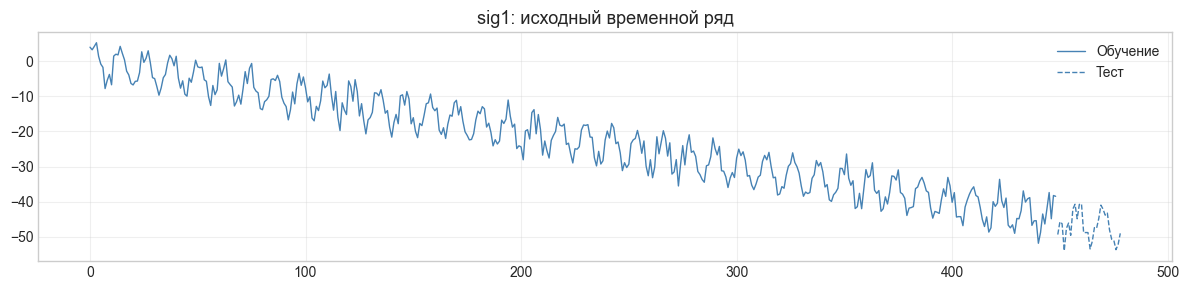

ADF p-value (tr1): 0.9329  -> НЕ стационарен


In [3]:
tr1 = sig1[:-30]
te1  = sig1[-30:]
idx1  = np.arange(len(sig1))

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(idx1[:len(tr1)], tr1, label='Обучение', color='steelblue', linewidth=1.0)
ax.plot(idx1[len(tr1):], te1,  label='Тест', color='steelblue', linestyle='--', linewidth=1.0)
ax.set_title('sig1: исходный временной ряд', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

_, pv1, *_ = adfuller(tr1)
status1 = 'стационарен' if pv1 < 0.05 else 'НЕ стационарен'
print(f"ADF p-value (tr1): {pv1:.4f}  -> {status1}")

Наблюдается нисходящий тренд. Ряд нестационарен (p-value = 0.93). Прямое применение ARMA невозможно без предобработки.

2: Достижение стационарности (TES)

Период TS1: 479
Период 479 слишком велик (max=224), применяем Holt
ADF остатков: 0.1830  - НЕ стационарны


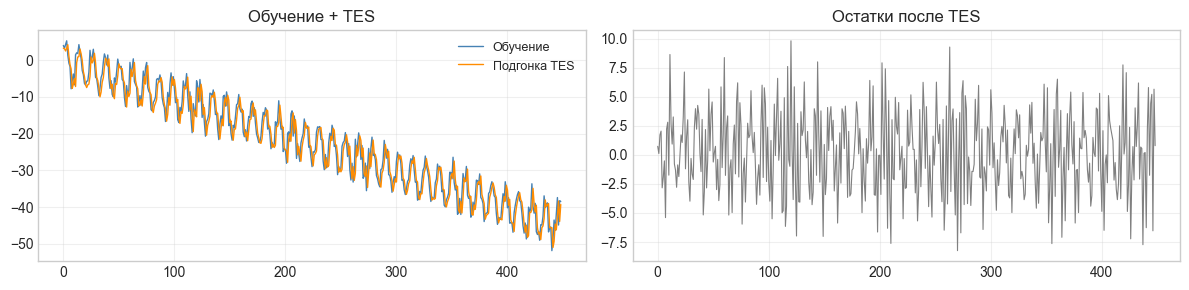

In [4]:
def detect_period(data):
    n = len(data)
    fft_v = np.fft.rfft(data - data.mean())
    pw = np.abs(fft_v) ** 2
    fr = np.fft.rfftfreq(n)
    peak = np.argmax(pw[1:]) + 1
    dom_fr = fr[peak]
    dom_per = 1.0 / dom_fr if dom_fr > 0 else np.inf
    return int(np.round(dom_per))

per1 = detect_period(sig1)
max_per1 = len(tr1) // 2
print(f"Период TS1: {per1}")

if 1 < per1 <= max_per1:
    tes1 = ExponentialSmoothing(tr1, trend='add', seasonal='add',
                                seasonal_periods=per1).fit(optimized=True)
else:
    print(f"Период {per1} слишком велик (max={max_per1}), применяем Holt")
    tes1 = Holt(tr1).fit(optimized=True)

resid1 = tr1 - tes1.fittedvalues

_, pv_r1, *_ = adfuller(resid1)
stat1 = 'стационарны' if pv_r1 < 0.05 else 'НЕ стационарны'
print(f"ADF остатков: {pv_r1:.4f}  - {stat1}")

fig, axs = plt.subplots(1, 2, figsize=(12, 3))
axs[0].plot(tr1, label='Обучение', color='steelblue', linewidth=1.0)
axs[0].plot(tes1.fittedvalues, label='Подгонка TES', color='darkorange', linewidth=1.0)
axs[0].set_title('Обучение + TES', fontsize=12)
axs[0].legend(fontsize=9)
axs[0].grid(True, alpha=0.3)

axs[1].plot(resid1, color='gray', linewidth=0.8)
axs[1].set_title('Остатки после TES', fontsize=12)
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

FFT определил период равным длине ряда. Применён метод Холта без сезонности. Остатки колеблются около нуля, но ADF p-value = 0.18 указывает на остаточную нестационарность. Холт убрал тренд, но автокорреляция сохраняется.

3: Определение порядка AR модели (PACF)

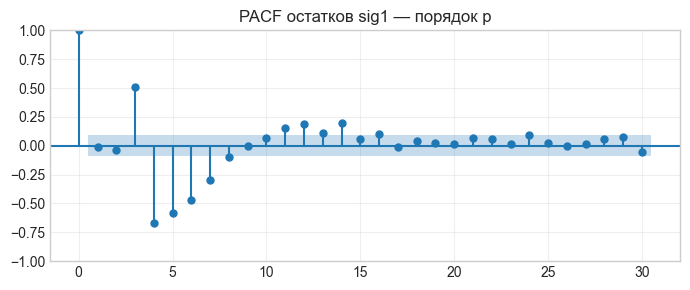

In [5]:
fig, ax = plt.subplots(figsize=(7, 3))
plot_pacf(resid1, lags=30, ax=ax, title="PACF остатков sig1 — порядок p")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Выбор p (последний значимый лаг PACF)

In [6]:
pv, cp = pacf(resid1, nlags=30, alpha=0.05)
sig_p = np.where(np.abs(pv[1:]) > (cp[1:, 1] - pv[1:]))[0]
p_val1 = int(sig_p[-1]) + 1 if len(sig_p) > 0 else 1
print(f"Порядок AR: p = {p_val1}")

Порядок AR: p = 29


Значимые лаги PACF тянутся до 29. Остатки зависят от далёкого прошлого следствие неполной стационарности.

4: Прогнозирование AR(p)

In [7]:
pv, cp = pacf(resid1, nlags=30, alpha=0.05)
sig_p = np.where(np.abs(pv[1:]) > (cp[1:, 1] - pv[1:]))[0]
p_val1 = int(sig_p[-1]) + 1 if len(sig_p) > 0 else 1
print(f"Порядок AR: p = {p_val1}")

Порядок AR: p = 29


AR(p) на остатках TES

In [8]:
ar_m1 = ARIMA(resid1, order=(p_val1, 0, 0)).fit()
ar_pred_r1 = ar_m1.forecast(steps=30)

Восстановление прогноза: TES + AR остатки

MSE AR(29) для sig1: 66.5665


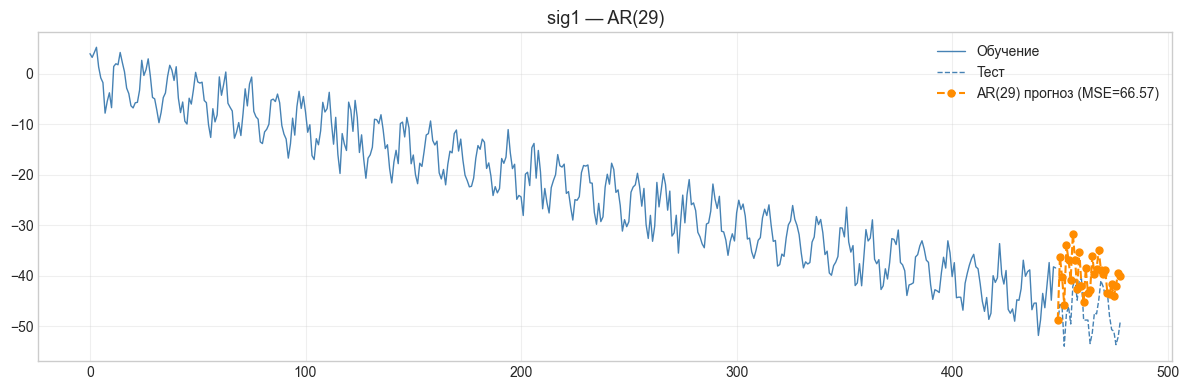

In [9]:
tes_fc1 = tes1.forecast(30)
ar_pred1 = tes_fc1 + ar_pred_r1
mse_ar1 = mean_squared_error(te1, ar_pred1)
print(f"MSE AR({p_val1}) для sig1: {mse_ar1:.4f}")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(idx1[:len(tr1)], tr1, label='Обучение', color='steelblue', linewidth=1.0)
ax.plot(idx1[len(tr1):], te1,  label='Тест', color='steelblue', linestyle='--', linewidth=1.0)
ax.plot(idx1[len(tr1):], ar_pred1,
        label=f'AR({p_val1}) прогноз (MSE={mse_ar1:.2f})',
        color='darkorange', linestyle='--', marker='o', markersize=5)
ax.set_title(f'sig1 — AR({p_val1})', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

AR(29) попадает в общий диапазон, но прогноз завышен. MSE = 66.56 — значительная ошибка. Причина — остатки после Холта не полностью стационарны.

5: Определение порядка MA модели (ACF)

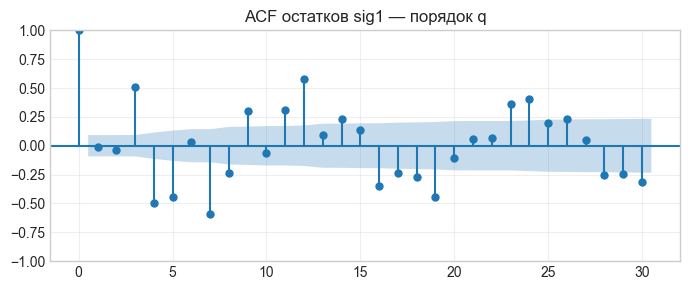

In [10]:
fig, ax = plt.subplots(figsize=(7, 3))
plot_acf(resid1, lags=30, ax=ax, title="ACF остатков sig1 — порядок q")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

6: Прогнозирование MA(q)
Автоматический выбор q (последний значимый лаг ACF)

In [11]:
av, ca = acf(resid1, nlags=30, alpha=0.05)
sig_a = np.where(np.abs(av[1:]) > (ca[1:, 1] - av[1:]))[0]
q_val1 = int(sig_a[-1]) + 1 if len(sig_a) > 0 else 1
print(f"Порядок MA: q = {q_val1}")

Порядок MA: q = 30


ACF показывает значимые корреляции на всех 30 лагах — признак нестационарности. Автоматически выбран максимальный порядок.

MA(q) на остатках TES

In [12]:
ma_m1 = ARIMA(resid1, order=(0, 0, q_val1)).fit()
ma_pred_r1 = ma_m1.forecast(steps=30)

Восстановление прогноза

MSE MA(30) для sig1: 67.8185


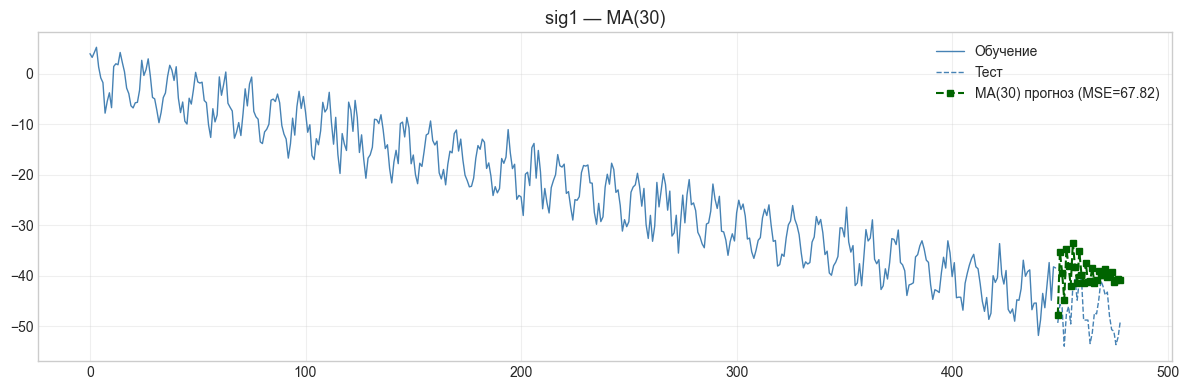

In [13]:
ma_pred1 = tes_fc1 + ma_pred_r1
mse_ma1 = mean_squared_error(te1, ma_pred1)
print(f"MSE MA({q_val1}) для sig1: {mse_ma1:.4f}")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(idx1[:len(tr1)], tr1, label='Обучение', color='steelblue', linewidth=1.0)
ax.plot(idx1[len(tr1):], te1,  label='Тест', color='steelblue', linestyle='--', linewidth=1.0)
ax.plot(idx1[len(tr1):], ma_pred1,
        label=f'MA({q_val1}) прогноз (MSE={mse_ma1:.2f})',
        color='darkgreen', linestyle='--', marker='s', markersize=5)
ax.set_title(f'sig1 — MA({q_val1})', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

MA(30) даёт MSE = 67.82 чуть хуже AR(29). Визуально прогнозы схожи, но MA хуже захватывает резкие отклонения.

### Ряд sig2

1: Разделение на обучающую и тестовую выборки

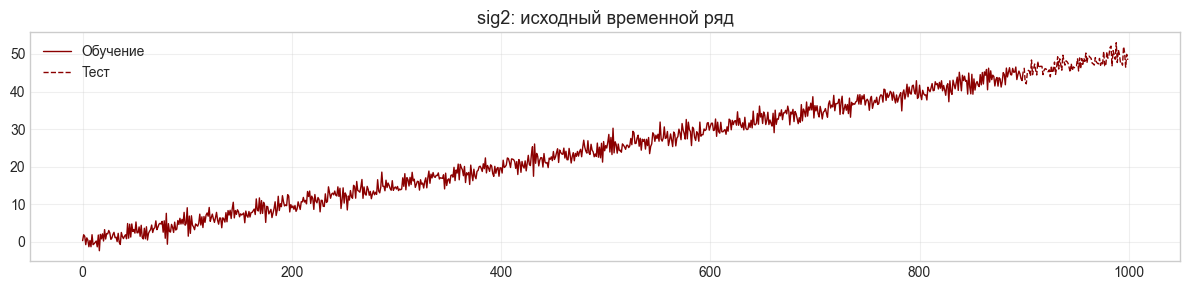

ADF p-value (tr2): 0.9471  - НЕ стационарен


In [14]:
tr2 = sig2[:-100]
te2  = sig2[-100:]
idx2  = np.arange(len(sig2))

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(idx2[:len(tr2)], tr2, label='Обучение', color='darkred', linewidth=1.0)
ax.plot(idx2[len(tr2):], te2,  label='Тест', color='darkred', linestyle='--', linewidth=1.0)
ax.set_title('sig2: исходный временной ряд', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

_, pv2, *_ = adfuller(tr2)
status2 = 'стационарен' if pv2 < 0.05 else 'НЕ стационарен'
print(f"ADF p-value (tr2): {pv2:.4f}  - {status2}")

Ряд sig2 демонстрирует выраженный восходящий тренд. ADF p-value = 0.95 подтверждает нестационарность.

2: Достижение стационарности

Период TS2: 1000
Период 1000 слишком велик (max=450), применяем Holt
ADF остатков: 0.0000  -> стационарны


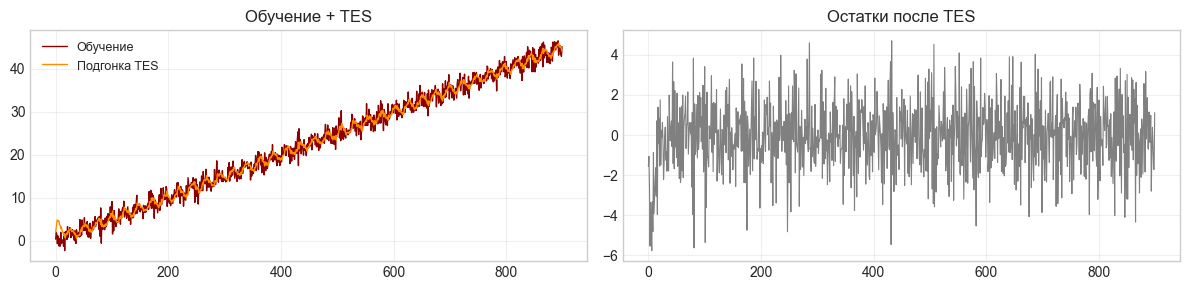

In [15]:
per2 = detect_period(sig2)
max_per2 = len(tr2) // 2
print(f"Период TS2: {per2}")

if 1 < per2 <= max_per2:
    tes2 = ExponentialSmoothing(tr2, trend='add', seasonal='add',
                                seasonal_periods=per2).fit(optimized=True)
else:
    print(f"Период {per2} слишком велик (max={max_per2}), применяем Holt")
    tes2 = Holt(tr2).fit(optimized=True)

resid2 = tr2 - tes2.fittedvalues

_, pv_r2, *_ = adfuller(resid2)
stat2 = 'стационарны' if pv_r2 < 0.05 else 'НЕ стационарны'
print(f"ADF остатков: {pv_r2:.4f}  -> {stat2}")

fig, axs = plt.subplots(1, 2, figsize=(12, 3))
axs[0].plot(tr2, label='Обучение', color='darkred', linewidth=1.0)
axs[0].plot(tes2.fittedvalues, label='Подгонка TES', color='darkorange', linewidth=1.0)
axs[0].set_title('Обучение + TES', fontsize=12)
axs[0].legend(fontsize=9)
axs[0].grid(True, alpha=0.3)

axs[1].plot(resid2, color='gray', linewidth=0.8)
axs[1].set_title('Остатки после TES', fontsize=12)
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Как и в sig1, FFT ошибочно определил период. Применён Холт. Остатки колеблются строго около нуля. ADF p-value = 0.0000 — стационарность достигнута. Результат лучше, чем для sig1.

3: PACF

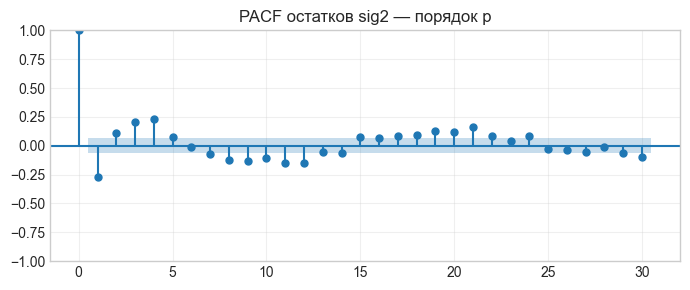

In [16]:
fig, ax = plt.subplots(figsize=(7, 3))
plot_pacf(resid2, lags=30, ax=ax, title="PACF остатков sig2 — порядок p")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

PACF остатков sig2 выглядит чище. Значимых лагов меньше, они сосредоточены в начале.

4: Прогноз AR

Порядок AR: p = 30
MSE AR(30) для sig2: 21.2415


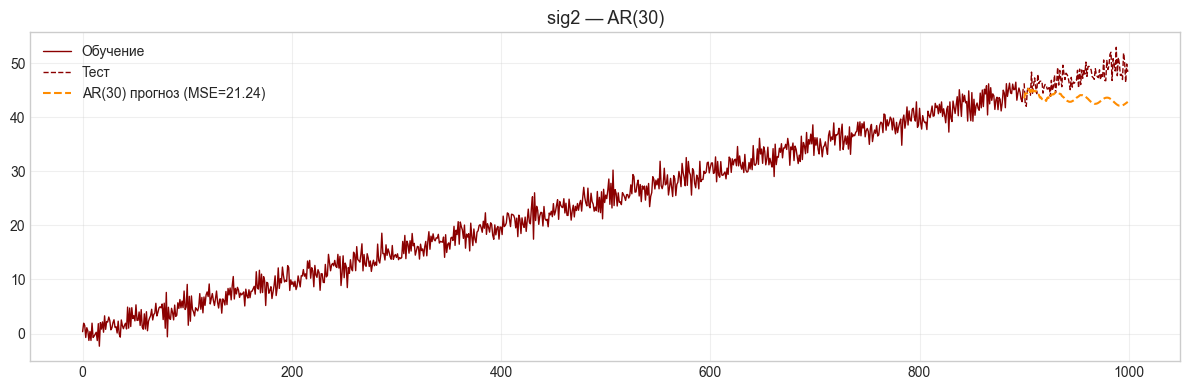

In [17]:
pv2, cp2 = pacf(resid2, nlags=30, alpha=0.05)
sig_p2 = np.where(np.abs(pv2[1:]) > (cp2[1:, 1] - pv2[1:]))[0]
p_val2 = int(sig_p2[-1]) + 1 if len(sig_p2) > 0 else 1
print(f"Порядок AR: p = {p_val2}")

ar_m2 = ARIMA(resid2, order=(p_val2, 0, 0)).fit()
ar_pred_r2 = ar_m2.forecast(steps=100)

tes_fc2 = tes2.forecast(100)
ar_pred2 = tes_fc2 + ar_pred_r2
mse_ar2 = mean_squared_error(te2, ar_pred2)
print(f"MSE AR({p_val2}) для sig2: {mse_ar2:.4f}")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(idx2[:len(tr2)], tr2, label='Обучение', color='darkred', linewidth=1.0)
ax.plot(idx2[len(tr2):], te2,  label='Тест', color='darkred', linestyle='--', linewidth=1.0)
ax.plot(idx2[len(tr2):], ar_pred2,
        label=f'AR({p_val2}) прогноз (MSE={mse_ar2:.2f})',
        color='darkorange', linestyle='--')
ax.set_title(f'sig2 — AR({p_val2})', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

AR(30) даёт MSE = 21.22 в три раза меньше, чем для sig1. Качественная предобработка дала результат. Прогноз немного ниже тестового ряда, но общий уровень схвачен верно.

5: ACF тест, определяем порядок q

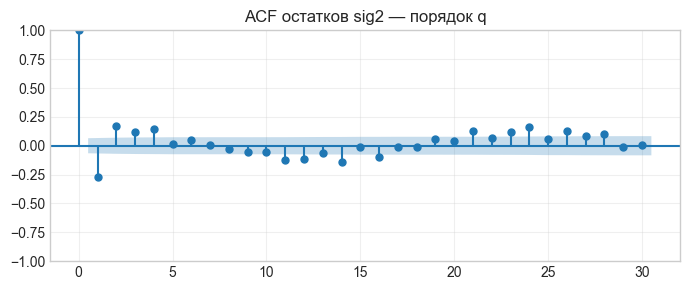

In [18]:
fig, ax = plt.subplots(figsize=(7, 3))
plot_acf(resid2, lags=30, ax=ax, title="ACF остатков sig2 — порядок q")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

ACF остатков sig2 чище, значимые корреляции ближе к нулю. Это подтверждает стационарность.

6: Прогноз MA

Порядок MA: q = 28


c:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


MSE MA(28) для sig2: 21.7579


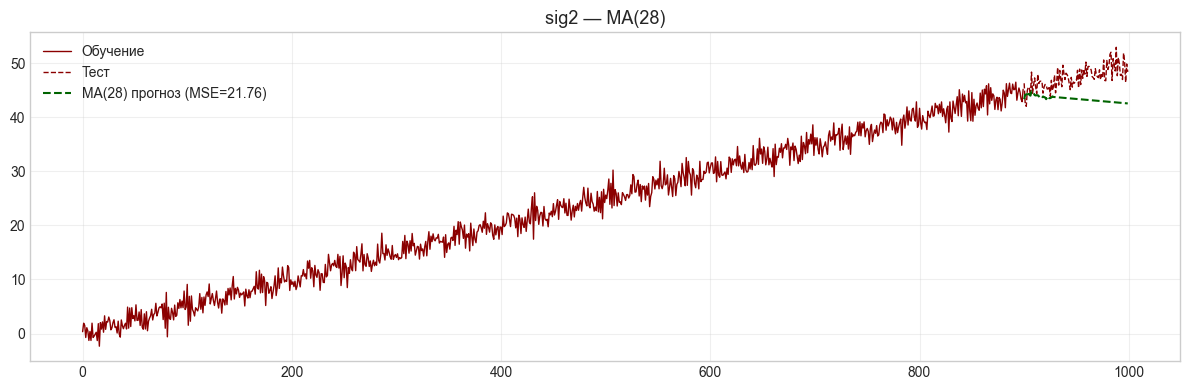

In [19]:
av2, ca2 = acf(resid2, nlags=30, alpha=0.05)
sig_a2 = np.where(np.abs(av2[1:]) > (ca2[1:, 1] - av2[1:]))[0]
q_val2 = int(sig_a2[-1]) + 1 if len(sig_a2) > 0 else 1
print(f"Порядок MA: q = {q_val2}")

ma_m2 = ARIMA(resid2, order=(0, 0, q_val2)).fit()
ma_pred_r2 = ma_m2.forecast(steps=100)

ma_pred2 = tes_fc2 + ma_pred_r2
mse_ma2 = mean_squared_error(te2, ma_pred2)
print(f"MSE MA({q_val2}) для sig2: {mse_ma2:.4f}")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(idx2[:len(tr2)], tr2, label='Обучение', color='darkred', linewidth=1.0)
ax.plot(idx2[len(tr2):], te2,  label='Тест', color='darkred', linestyle='--', linewidth=1.0)
ax.plot(idx2[len(tr2):], ma_pred2,
        label=f'MA({q_val2}) прогноз (MSE={mse_ma2:.2f})',
        color='darkgreen', linestyle='--')
ax.set_title(f'sig2 — MA({q_val2})', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

MA(28) даёт MSE = 21.76практически равно AR(30). Оба метода для sig2 равнозначны. Прогноз убывает чуть быстрее реального ряда, но начальный уровень угадан верно.

Качество прогноза зависит от предобработки. Где Холт полностью убрал нестационарность (sig2), ошибки в три раза меньше.